Felső szintű kulcsok:
["preictal_segment_1"]

A szegmens belső kulcsai:
["sampling_frequency", "sequence", "data", "data_length_sec", "channels"]

sampling_frequency = 399.609756097561
sequence = 1.0
data_length_sec = 600.0

channels:
Any["NVC1202_32_002_Ecog_c001" "NVC1202_32_002_Ecog_c002" "NVC1202_32_002_Ecog_c003" "NVC1202_32_002_Ecog_c004" "NVC1202_32_002_Ecog_c005" "NVC1202_32_002_Ecog_c006" "NVC1202_32_002_Ecog_c007" "NVC1202_32_002_Ecog_c008" "NVC1202_32_002_Ecog_c009" "NVC1202_32_002_Ecog_c010" "NVC1202_32_002_Ecog_c011" "NVC1202_32_002_Ecog_c012" "NVC1202_32_002_Ecog_c013" "NVC1202_32_002_Ecog_c014" "NVC1202_32_002_Ecog_c015" "NVC1202_32_002_Ecog_c016"]

A data mátrix mérete:
(16, 239766)

A data típusa:
Matrix{Float64}

Összefoglaló a data mátrixról:
16×239766 Matrix{Float64}

Csatornák száma: 16
Minták száma: 239766
Az adat reprezentációja:
- sorok    = csatornák
- oszlopok = időminták
- data[i, j] = az i-edik csatorna amplitúdója a j-edik időpillanatban

Kiválasztott csato

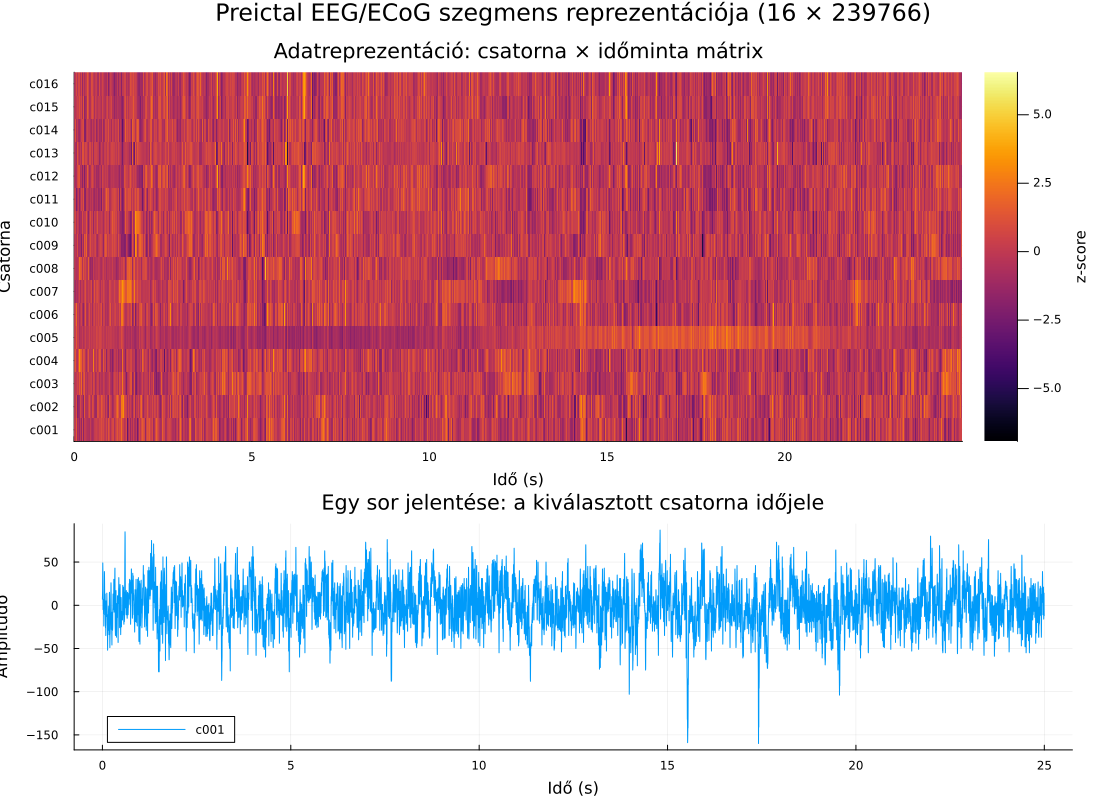


Az ábra elmentve: preictal_segment_representation.png


In [1]:
using MAT, Plots, Statistics

# interictal: két roham közti időszakasz
# preictal: roham előtti időszakasz
# test: ugyanaz a szerkezet

# =========================
# 1. Fájl beolvasása
# =========================
data = matread("Dog_1/Dog_1_preictal_segment_0001.mat")

println("Felső szintű kulcsok:")
println(collect(keys(data)))

segment = data["preictal_segment_1"]

println("\nA szegmens belső kulcsai:")
println(collect(keys(segment)))

# Az adatszerkezet lényegében egy Dict{String, Any}, és a következő kulcsokat tartalmazza:
# sampling_frequency - mintavételezési frekvencia: hány minta van másodpercenként
fs = segment["sampling_frequency"]
println("\nsampling_frequency = ", fs)   # kb. 399.61 Hz

# sequence - szegmens sorszáma
println("sequence = ", segment["sequence"])

# data_length_sec - a szegmens hossza másodpercben
data_length_sec = segment["data_length_sec"]
println("data_length_sec = ", data_length_sec)   # 600.0 sec

# channels - a csatornák azonosítói
channels = segment["channels"]
println("\nchannels:")
println(channels)

# data - maga az EEG jel
eeg = segment["data"]

println("\nA data mátrix mérete:")
println(size(eeg))   # (16, 239766) -> 16 sor (csatorna), 239766 oszlop (időminta)

println("\nA data típusa:")
println(typeof(eeg)) # Matrix{Float64}

println("\nÖsszefoglaló a data mátrixról:")
println(summary(eeg))

n_channels, n_samples = size(eeg)

println("\nCsatornák száma: ", n_channels)
println("Minták száma: ", n_samples)

# =========================
# 2. Rövid magyarázat
# =========================
println("""
Az adat reprezentációja:
- sorok    = csatornák
- oszlopok = időminták
- data[i, j] = az i-edik csatorna amplitúdója a j-edik időpillanatban
""")

# =========================
# 3. Rövid időablak kiválasztása a szemléltetéshez
# =========================
# A teljes 10 perc túl sűrű lenne, ezért csak egy rövid időablakot ábrázolunk.
time_window_in_sec = 25

# Ennyi minta tartozik a kiválasztott időablakhoz
nwin = min(Int(round(time_window_in_sec * fs)), n_samples)

# Az első nwin mintát vesszük
eeg_win = eeg[:, 1:nwin]

# Időtengely másodpercben
t = (0:nwin-1) ./ fs

# =========================
# 4. Csatornánként normalizálás a heatmaphez
# =========================
# Ez azért hasznos, mert így a különböző amplitúdójú csatornák jobban összehasonlíthatók.
eeg_norm = Array{Float64}(undef, size(eeg_win))

for ch in 1:n_channels
    x = Float64.(eeg_win[ch, :])
    μ = mean(x)
    σ = std(x)

    if σ > 0
        eeg_norm[ch, :] = (x .- μ) ./ σ
    else
        eeg_norm[ch, :] = x .- μ
    end
end

# =========================
# 5. Rövidített csatornanevek a tengelyhez
# =========================
# Például: NVC1202_32_002_Ecog_c001 -> c001
short_channels = String[]

for c in channels
    s = String(c)
    m = match(r"c\d+$", s)
    if m === nothing
        push!(short_channels, s)
    else
        push!(short_channels, m.match)
    end
end

# =========================
# 6. Egy kiválasztott csatorna időjele
# =========================
selected_channel = 1
raw_signal = eeg[selected_channel, 1:nwin]

println("Kiválasztott csatorna: ", short_channels[selected_channel])

# =========================
# 7. Ábra készítése
# =========================
layout_style = @layout [a{0.62h}; b{0.38h}]

p1 = heatmap(
    t,
    1:n_channels,
    eeg_norm,
    xlabel = "Idő (s)",
    ylabel = "Csatorna",
    yticks = (1:n_channels, short_channels),
    title = "Adatreprezentáció: csatorna × időminta mátrix",
    colorbar_title = "z-score"
)

p2 = plot(
    t,
    raw_signal,
    xlabel = "Idő (s)",
    ylabel = "Amplitúdó",
    label = short_channels[selected_channel],
    title = "Egy sor jelentése: a kiválasztott csatorna időjele"
)

final_plot = plot(
    p1, p2,
    layout = layout_style,
    size = (1100, 800),
    plot_title = "Preictal EEG/ECoG szegmens reprezentációja ($(n_channels) × $(n_samples))"
)

display(final_plot)

savefig(final_plot, "preictal_segment_representation.png")
println("\nAz ábra elmentve: preictal_segment_representation.png")

In [3]:
#=
Teendok:

1. minden .mat szegmensbol kell csinalni egy egy fix hosszusagu feature vektort es ebbol kell felepiteni a tanitohalmazt
Tehat: .mat -> adat matrix -> feature extraction -> feature vector -> SVM

================================================================================
NAGY KEP / MI TORTENIK EBBEN A KODBAN?
====================================================================

A cel:
    Dog_1 mappaban levo .mat EEG szegmensekbol keszitunk gepi tanulasi adatot,
    majd SVM-mel megprobaljuk eldonteni, hogy egy szegmens:

        0 = interictal  -> rohamok kozotti allapot
        1 = preictal    -> roham elotti allapot

A vegrehajtasi sorrend nagy vonalakban:

    1. Beolvassuk a .mat fajlokat.
    2. Minden fajlbol kiszedjuk:
        - EEG adatmatrix
        - mintaveteli frekvencia, fs
        - csatornanevek
    3. Minden EEG szegmensbol PFE feature-oket szamolunk:
        - az EEG-t 5 masodperces, atfedett ablakokra bontjuk
        - minden ablakban, minden csatornara permutation fuzzy entropy-t szamolunk
        - csatornankent osszefoglaljuk a PFE idosort 7 statisztikaval
    4. Minden .mat fajlbol egy fix hosszu feature-vektor lesz.
    5. Ezekbol osszeall:
        - X: sorok = szegmensek, oszlopok = feature-ok
        - y: cimkek, 0 vagy 1
    6. Train/test split.
    7. SVM-hez standardizalas csak train alapjan.
    8. A train halmazon belul balanszirozunk, mert sokkal tobb interictal van.
    9. Belső validacion cost/gamma parametereket keresunk.
   10. A legjobb parameterekkel vegso SVM-et tanitunk.
   11. Test halmazon kiertékelunk.
   12. Diagramokat mentunk, hogy ertelmezheto legyen az adat es a modell.

megjegyzes:
    A kulon cimkezetlen test_segment fajlokat ez a kod meg NEM hasznalja.
    Itt csak a preictal/interictal cimkezett fajlokbol keszul tanito- es teszthalmaz.
=#

# =========================================================
# Minden .mat szegmens -> fix hosszu feature vektor
# ebbol tanitohalmaz kesobb: X, y
# =========================================================

using MAT                 # MATLAB .mat fajlok beolvasasa: matread(...)
using Statistics          # mean, std, median, quantile stb.
using Random              # random splithez, shuffle-hoz
using LIBSVM              # SVM modell tanitas es predikcio
using Plots               # altalanos abra keszites
using StatsPlots          # boxplot es statisztikai abrak
using MultivariateStats   # PCA

# Alap abra meret es felbontas.
# Ez csak kenyelmi beallitas, hogy a mentett PNG-k olvashatoak legyenek.
default(size = (950, 550), dpi = 140)

# =================================================
# 1. Alap matematikai / feature extraction fuggvenyek
# ==========================================

# csak normalizalas (1D jelet)
#
# Mit csinal?
#   Egyetlen 1D jelbol z-score normalizalt jelet keszit.
#
# Keplet:
#   z = (x - atlag) / szoras
#
# Miért kell?
#   EEG csatornak es ablakok amplitudoja eltero lehet.
#   A z-score miatt nem az abszolut mertekegyseget, hanem a relativ elterest nezzuk.
#
# Ha a szoras 0, akkor nem osztunk nullaval, csak levonjuk az atlagot.
function zscore1d(x::AbstractVector{<:Real})
    xf = Float64.(x)                      # minden bemeneti erteket Float64-re alakitunk
    μ = mean(xf)                          # atlag
    σ = std(xf; corrected = false)        # populacios szoras, corrected=false: N-nel oszt
    return σ > 0 ? (xf .- μ) ./ σ : xf .- μ
end

# lokalis mintahoz -> perm. sorrend
#
# Mit csinal?
#   Egy rovid vektor ertekeit nem nagysag szerint adja vissza,
#   hanem azt, hogy az elemek milyen sorrendben vannak.
#
# Pelda:
#   v = [3, 1, 2]
#   novekvo sorrend: 1(index=2), 2(index=3), 3(index=1)
#   ordinal_pattern(v) = (2, 3, 1)
#
# Miért kell?
#   A permutation entropy alapja nem a konkret amplitudo,
#   hanem a lokalis sorrendminta.
function ordinal_pattern(v::AbstractVector{<:Real})
    idx = collect(eachindex(v)) # stabil rendezes (egyenloseg eseten index szerint) 

    # Az indexeket rendezzuk a hozzajuk tartozo ertek szerint.
    # by = i -> (v[i], i)
    #   eloszor v[i] szerint rendez,
    #   ha ket ertek egyenlo, akkor i szerint, vagyis determinisztikus marad.
    sort!(idx, by = i -> (v[i], i))

    # Tuple-kent adjuk vissza, mert kesobb Dict kulcskent hasznaljuk.
    # A tuple nem modosithato, stabilabb kulcs, mint egy Vector.
    return Tuple(idx)
end

# ha mintaban az ertekek kozel vannak, akkor bizonytalan sorrend, kulonben stabil
#
# Mit csinal?
#   Egy rovid lokalis mintara megmondja, mennyire megbizhato annak sorrendje.
#
# Otlet:
#   Ha ket ertek majdnem egyenlo, akkor kis zaj is felcserelheti oket.
#   Ilyenkor az ordinalis minta bizonytalan, kisebb sulyt kap.
#
# Visszateresi ertek:
#   kb. 0 -> bizonytalan sorrend
#   kb. 1 -> stabil sorrend
#
# Parameterek:
#   r     -> skala, mekkora kulonbseg szamit mar erdeminek
#   alpha -> gorbe meredeksege
function fuzzy_confidence(v::AbstractVector{<:Real}; r::Float64 = 0.2, alpha::Float64 = 2.0)
    # mennyire "stabil" a sorrend
    s = sort(Float64.(v))                 # ertekek novekvo sorrendben

    # Egyetlen elemnek nincs bizonytalan sorrendje.
    if length(s) < 2
        return 1.0
    end

    gaps = diff(s)                        # szomszedos rendezett ertekek kozti kulonbsegek
    gmin = minimum(abs.(gaps))            # legkisebb res: ez hatarozza meg a bizonytalansagot

    # kicsi res   -> bizonytalan       -> kisebb weight
    # nagyobb res -> stabilabb sorrend -> nagyobb weight
    #
    # Ha gmin = 0, akkor exp(0) = 1, tehat a visszateres 0.
    # Ha gmin nagy, akkor exp(-nagy) kb. 0, tehat a visszateres 1.
    return 1.0 - exp(- (gmin / r)^alpha)
end

# teljes 1D jelre -> perm. fuzzy entropy
# normalizalas
# embedding vektor
# minden mintara: ordinalis mintazat es fuzzy suly
# sulyozott gyakorisag
# entropia vegen
#
# Mit szamol?
#   Egy 1D jelre permutation fuzzy entropy-t.
#
# Nagy otlet:
#   Vegigcsusztatunk egy m hosszu mintat a jelen.
#   Minden kis mintabol ordinalis mintat csinalunk.
#   A mintakat nem sima +1 darabbal szamoljuk, hanem fuzzy sulyt adunk nekik.
#   Vegul a mintak eloszlasabol Shannon-entropiat szamolunk.
#
# Jelentes:
#   alacsonyabb PFE -> kevesebb / szabalyosabb sorrendminta
#   magasabb PFE    -> valtozatosabb / komplexebb sorrendminta
function permutation_fuzzy_entropy(
    x::AbstractVector{<:Real};
    m::Int = 3,                         # embedding dimenzio, hany pontbol alljon egy lokalis minta
    tau::Int = 1,                       # kesleltetes, hany mintankent valasszunk pontokat
    r::Float64 = 0.2,                   # fuzzy confidence skala
    alpha::Float64 = 2.0,               # fuzzy confidence meredekseg
    normalize_input::Bool = true,       # normalizaljuk-e a bemeneti jelet
    normalize_entropy::Bool = true      # 0-1 kozeli tartomanyra normalizaljuk-e az entropiat
)
    m >= 2 || error("m legalább 2 legyen.")
    tau >= 1 || error("tau legalább 1 legyen.")

    # A PFE-t tipikusan normalizalt jelen szamoljuk, mert akkor az r parameter
    # nem fugg annyira az abszolut amplitudotol.
    xwork = normalize_input ? zscore1d(x) : Float64.(x)

    N = length(xwork)

    # M = hany darab m hosszu, tau lepesu mintat lehet kivenni a jelbol.
    # Pelda m=3, tau=1:
    #   [x1,x2,x3], [x2,x3,x4], ...
    # Pelda m=3, tau=2:
    #   [x1,x3,x5], [x2,x4,x6], ...
    M = N - (m - 1) * tau
    M > 0 || error("A jel túl rövid a megadott m és tau értékekhez.")

    # counts: ordinalis minta -> sulyozott elofordulas
    # Any-t hasznalunk, mert Tuple-ok lesznek a kulcsok.
    counts = Dict{Any, Float64}()
    total_weight = 0.0

    for i in 1:M
        # Lokalis embedding vektor: m darab pont tau tavolsaggal.
        v = [xwork[i + (k - 1) * tau] for k in 1:m]

        # Sorrendminta, pelda: (2,3,1)
        pat = ordinal_pattern(v)

        # Mennyire megbizhato ez a sorrend?
        w = fuzzy_confidence(v; r = r, alpha = alpha)

        # A minta gyakorisagat nem 1-gyel, hanem w-vel noveljuk.
        counts[pat] = get(counts, pat, 0.0) + w
        total_weight += w
    end

    # Ha minden suly 0, akkor nincs ertelmezheto eloszlas.
    total_weight > 0 || return 0.0

    # Shannon-entropia a sulyozott ordinalis mintaeloszlasbol.
    H = 0.0
    for c in values(counts)
        p = c / total_weight
        if p > 0
            H -= p * log(p)
        end
    end

    # normalizalas
    # m hosszu mintabol maximum m! kulonbozo ordinalis minta lehet.
    # A maximalis entropia log(m!), ezzel osztva kb. 0-1 koze kerul.
    return normalize_entropy ? H / log(factorial(m)) : H
end

# idoablak index-intervallum (pl. 5s vagy 2.5s, ...)
#
# Mit csinal?
#   Egy hosszu jelhez visszaadja azokat az index-tartomanyokat,
#   amelyek 5 masodperces, 2.5 masodperces lepessel csusztatott ablakokat jelentenek.
#
# Pelda fs=400, win_sec=5:
#   win_len = 2000 minta
#   step_len = 1000 minta
function build_window_ranges(
    n_samples::Int,
    fs::Real;
    win_sec::Float64 = 5.0,
    step_sec::Float64 = 2.5
)
    win_len  = Int(round(win_sec * fs))
    step_len = Int(round(step_sec * fs))

    win_len > 0  || error("Az ablakhossz legyen pozitív.")
    step_len > 0 || error("A lépésköz legyen pozitív.")

    ranges = UnitRange{Int}[]
    start_idx = 1

    # Csak teljes ablakokat veszunk fel.
    # Ami a jel vegen mar nem fer bele teljesen, azt eldobjuk.
    while start_idx + win_len - 1 <= n_samples
        push!(ranges, start_idx:(start_idx + win_len - 1))
        start_idx += step_len
    end

    return ranges
end

# teles EEG matrix -> PFE matrix
#
# Bemenet:
#   eeg: csatornak x idomintak matrix
#
# Kimenet:
#   pfe_matrix: ablakok x csatornak matrix
#
# Jelentes:
#   pfe_matrix[widx, ch] = adott idoablakban adott csatorna PFE erteke
function extract_pfe_matrix(
    eeg::AbstractMatrix{<:Real},
    fs::Real;
    win_sec::Float64 = 5.0,
    step_sec::Float64 = 2.5,
    m::Int = 3,
    tau::Int = 1,
    r::Float64 = 0.2,
    alpha::Float64 = 2.0
)
    n_channels, n_samples = size(eeg)
    windows = build_window_ranges(n_samples, fs; win_sec = win_sec, step_sec = step_sec)

    # sorok    = ablakok, 
    # oszlopok = csatornák
    pfe_matrix = Matrix{Float64}(undef, length(windows), n_channels)

    for (widx, rng) in enumerate(windows)
        for ch in 1:n_channels
            # view: nem masolja le az adatot, csak nezetet ad az adott csatorna adott ablakara.
            x = view(eeg, ch, rng)

            # Minden csatorna minden ablakara kiszamoljuk a PFE-t.
            pfe_matrix[widx, ch] = permutation_fuzzy_entropy(
                x;
                m = m,
                tau = tau,
                r = r,
                alpha = alpha,
                normalize_input = true,
                normalize_entropy = true
            )
        end
    end

    return pfe_matrix
end

# Egy szamsorbol 7 statisztikai osszefoglalo feature-t keszit.
#
# Ez azert kell, mert a pfe_matrix egy csatornara egy teljes idosort ad.
# Az SVM viszont fix hosszu feature-vektort var.
# Ezert minden csatorna PFE-idosorat osszefoglaljuk:
#   mean, std, min, q25, median, q75, max
function summarize_series(x::AbstractVector{<:Real})
    xf = Float64.(x)
    return Float64[
        mean(xf),
        std(xf; corrected = false),
        minimum(xf),
        quantile(xf, 0.25),
        median(xf),
        quantile(xf, 0.75),
        maximum(xf)
    ]
end

# NVC1202_32_002_Ecog_c001 → c001 (ai generalta, regex varazslat)
#
# Mit csinal?
#   Hosszu csatornanevbol kiszedi a vegi c001/c005/stb. reszt.
#
# Pelda:
#   "NVC1202_32_002_Ecog_c001" -> "c001"
function short_channel_name(c)
    s = String(c)
    m = match(r"c\d+$", s)
    return m === nothing ? s : m.match
end

# Minden csatornahoz legeneralja a feature-neveket.
#
# Ha van c001 es c002 csatorna, akkor pelda:
#   c001_mean, c001_std, ..., c001_max,
#   c002_mean, c002_std, ..., c002_max
function feature_names_from_channels(channels)
    stats = ["mean", "std", "min", "q25", "median", "q75", "max"]
    names = String[]
    for ch in channels
        sh = short_channel_name(ch)
        for st in stats
            push!(names, "$(sh)_$(st)")
        end
    end
    return names
end

# ------------------------------------------------------
# .mat filebol feature vektor
# --------------------------------------------------------

# Egy .mat fajlbol kiszedi:
#   eeg      -> EEG matrix
#   fs       -> mintaveteli frekvencia
#   channels -> csatornanevek
#
# A .mat fajlokban a fo kulcs tipikusan:
#   preictal_segment_1
# vagy:
#   interictal_segment_1
function load_segment_from_mat(filepath::AbstractString)
    data = matread(filepath)

    # pl. "preictal_segment_1" vagy "interictal_segment_1"
    # A kulcsok kozott megkeressuk azt, amelyikben szerepel a "segment" szo.
    seg_keys = filter(k -> occursin("segment", lowercase(k)), collect(keys(data)))
    isempty(seg_keys) && error("Nem találtam segment kulcsot ebben a fájlban: $filepath")

    segment = data[first(seg_keys)]

    eeg = Float64.(segment["data"])
    fs = Float64(segment["sampling_frequency"])
    channels = vec(segment["channels"])

    # Biztonsagi ellenorzes:
    # a tobbi kod azt feltetelezi, hogy:
    # sorok    = csatornak
    # oszlopok = idomintak
    #
    # Ha a fajlban forditva van, vagyis sorok=idomintak es oszlopok=csatornak,
    # akkor transzponaljuk.
    if size(eeg, 1) != length(channels) && size(eeg, 2) == length(channels)
        eeg = Matrix(eeg')
    end

    return eeg, fs, channels
end

# 1 db .mat -> vegso feature vector
#
# Ez a teljes feature extraction egyetlen fajlra:
#   .mat -> eeg, fs, channels
#   eeg -> pfe_matrix
#   pfe_matrix -> csatornankenti 7 statisztika
#   vegeredmeny: feat vektor + feature_nevek
function mat_to_feature_vector(
    filepath::AbstractString;
    win_sec::Float64 = 5.0,
    step_sec::Float64 = 2.5,
    m::Int = 3,
    tau::Int = 1,
    r::Float64 = 0.2,
    alpha::Float64 = 2.0
)
    eeg, fs, channels = load_segment_from_mat(filepath)

    # pfe_matrix merete:
    #   ablakok x csatornak
    pfe_matrix = extract_pfe_matrix(
        eeg, fs;
        win_sec = win_sec,
        step_sec = step_sec,
        m = m,
        tau = tau,
        r = r,
        alpha = alpha
    )

    n_windows, n_channels = size(pfe_matrix)

    # feat lesz az egyetlen fajlbol keszulo fix hosszu feature-vektor.
    feat = Float64[]

    # Csatornankent vegigmegyunk.
    # Egy csatorna PFE idosorat 7 statisztikaval foglaljuk ossze.
    for ch in 1:n_channels
        ch_series = view(pfe_matrix, :, ch)
        append!(feat, summarize_series(ch_series))
    end

    feature_names = feature_names_from_channels(channels)
    return feat, feature_names
end

# ----------------------------------------------------
# label a filenevbol
#    preictal -> 1
#    interictal -> 0
# ---------------------------------------------------------

# A cimket a fajlnevekbol allapitjuk meg.
# Ez csak a cimkezett train/valid/test belso splithez jo.
# A kulon cimkezetlen test_segment fajlokhoz ezt NEM hasznaljuk.
function label_from_filename(filepath::AbstractString)
    name = lowercase(basename(filepath))
    if occursin("preictal", name)
        return 1
    elseif occursin("interictal", name)
        return 0
    else
        error("Nem tudtam címkét meghatározni a fájlnévből: $filepath")
    end
end

# --------------------------------------------------------
# Tanitohalmaz (Dog_1)
# ---------------------------------------------------------

# felepiti a tanitohalmazt
# Dog_1 bol az osses .mat -> preicital es intericital
# mindegyikre mat_to_feature_vector
# egymas ala rakja ezeket es felepiti
# x: sorok = szegmens, oszlopok = feature
# y: labelek
#
# Ez a fuggveny a pipeline adatgyujto resze.
#
# Kimenet:
#   X             -> n_samples x n_features matrix
#   y             -> cimkek, 0/1
#   feature_names -> X oszlopnevei
#   file_list     -> melyik X sor melyik fajlbol jott
function build_training_set(
    root_dir::AbstractString;
    win_sec::Float64 = 5.0,
    step_sec::Float64 = 2.5,
    m::Int = 3,
    tau::Int = 1,
    r::Float64 = 0.2,
    alpha::Float64 = 2.0
)
    all_files = readdir(root_dir; join = true)

    # Csak a cimkezett fajlokat hasznaljuk:
    #   preictal vagy interictal .mat
    # A cimkezetlen test_segment fajlok itt nem kerulnek be.
    mat_files = filter(all_files) do f
        lf = lowercase(f)
        endswith(lf, ".mat") && (occursin("preictal", lf) || occursin("interictal", lf))
    end

    mat_files = sort(mat_files)
    isempty(mat_files) && error("Nem találtam preictal/interictal .mat fájlokat a mappában: $root_dir")

    feature_vectors = Vector{Vector{Float64}}()
    y = Int[]
    file_list = String[]
    feature_names = String[]

    for (i, filepath) in enumerate(mat_files)
        println("[$i / $(length(mat_files))] ", basename(filepath))

        # Egyetlen .mat fajlbol feature-vektor.
        feat, feat_names = mat_to_feature_vector(
            filepath;
            win_sec = win_sec,
            step_sec = step_sec,
            m = m,
            tau = tau,
            r = r,
            alpha = alpha
        )

        # Az elso fajlnal elmentjuk a feature neveket.
        # A tobbi fajlnal szigoruan ellenorizzuk, hogy ugyanazok-e.
        # Ez fontos: nem eleg csak a hossz egyezese, mert a csatornasorrend is szamit.
        if i == 1
            feature_names = feat_names
        else
            feat_names == feature_names ||
                error("Eltérő feature-nevek vagy csatornasorrend ebben a fájlban: $(basename(filepath))")
        end

        push!(feature_vectors, feat)
        push!(y, label_from_filename(filepath))
        push!(file_list, filepath)
    end

    # mintak, featurek
    n_samples = length(feature_vectors)
    n_features = length(feature_vectors[1])

    # A listabol tenyleges matrixot epitunk.
    # X sorai lesznek a fajlok/szegmensek, oszlopai a feature-ok.
    X = Matrix{Float64}(undef, n_samples, n_features)
    for i in 1:n_samples
        X[i, :] = feature_vectors[i]
    end

    return X, y, feature_names, file_list
end

# ---------------------------------------------------------
# SVM-hez segedfuggvenyek
# -----------------------------------------------------------=-

# Stratified split:
# ugy bontjuk train/test reszre, hogy mindket osztalybol
# legyen tanito es teszt adat is
#
# Miért kell?
#   Ha sima random splitet hasznalnank, elofordulhatna,
#   hogy a nagyon keves preictal mintabol nem kerul a testbe vagy trainbe.
function stratified_split(y; test_ratio::Float64 = 0.2, seed::Int = 42)
    rng = MersenneTwister(seed)

    train_idx = Int[]
    test_idx = Int[]

    for cls in sort(unique(y))
        idx = findall(==(cls), y)

        length(idx) >= 2 ||
            error("Tul keves minta van ebbol az osztalybol: $cls")

        shuffle!(rng, idx)

        n_test = round(Int, test_ratio * length(idx))
        n_test = clamp(n_test, 1, length(idx) - 1)

        append!(test_idx, idx[1:n_test])
        append!(train_idx, idx[(n_test + 1):end])
    end

    return sort(train_idx), sort(test_idx)
end

# standardizalas csak train alapjan
# fontos: a test adat statisztikajat nem hasznaljuk tanitas elott
#
# Miért kell SVM-hez?
#   Az SVM skalaerzekeny. Ha az egyik feature nagyobb szamtartomanyban mozog,
#   akkor indokolatlanul nagyobb hatasa lehet.
#
# Miért csak train alapjan?
#   Ha a test statisztikajat is hasznalnank, az adatszivargas lenne.
function fit_standardizer(X_train::AbstractMatrix{<:Real})
    μ = vec(mean(X_train; dims = 1))
    σ = vec(std(X_train; dims = 1, corrected = false))

    # ha valamelyik feature konstans, ne osszunk nullaval
    σ[σ .== 0.0] .= 1.0

    return μ, σ
end

# A mar megtanult μ, σ parameterekkel standardizalunk.
# Ugyanezt hasznaljuk trainre, validaciora, testre, kesobb cimkezetlen testre is.
function transform_standardizer(X::AbstractMatrix{<:Real}, μ, σ)
    return (Float64.(X) .- μ') ./ σ'
end

# majority class downsampling csak a train adaton
# igy az SVM nem tanulja meg azt, hogy mindig 0-t mondjon
#
# Miért kell?
#   A Dog_1 adatokban jellemzoen sokkal tobb interictal van, mint preictal.
#   Ha ezt igy tanitjuk, a modell megtanulhatja, hogy mindig 0-t mondjon.
#
# Mit csinal?
#   Kivalaszt ugyanannyi 0-s es 1-es mintat a tanito reszbol.
#
# Fontos:
#   Csak trainen hasznaljuk. Testen nem balanszirozunk.
function balanced_train_indices(y_local; seed::Int = 42)
    rng = MersenneTwister(seed)

    idx0 = findall(==(0), y_local)  # interictal
    idx1 = findall(==(1), y_local)  # preictal

    isempty(idx0) && error("Nincs interictal minta.")
    isempty(idx1) && error("Nincs preictal minta.")

    n = min(length(idx0), length(idx1))

    shuffle!(rng, idx0)
    shuffle!(rng, idx1)

    selected = vcat(idx0[1:n], idx1[1:n])
    shuffle!(rng, selected)

    return selected
end

# Egy helyre osszegyujtjuk a kiertékelési metrikakat.
#
# Nálunk:
#   pozitiv osztaly = 1 = preictal
#   negativ osztaly = 0 = interictal
#
# Jelentes:
#   TP: preictal volt, preictalnak mondta
#   TN: interictal volt, interictalnak mondta
#   FP: interictal volt, de preictalnak mondta -> fals riasztas
#   FN: preictal volt, de interictalnak mondta -> kihagyott preictal
function classification_metrics(y_true, y_pred)
    tp = sum((y_pred .== 1) .& (y_true .== 1))
    tn = sum((y_pred .== 0) .& (y_true .== 0))
    fp = sum((y_pred .== 1) .& (y_true .== 0))
    fn = sum((y_pred .== 0) .& (y_true .== 1))

    accuracy = mean(y_pred .== y_true)

    sensitivity = tp / max(tp + fn, 1)   # preictal felismeres
    specificity = tn / max(tn + fp, 1)   # interictal felismeres
    precision   = tp / max(tp + fp, 1)   # ha preictalt mond, milyen aranyban igaz

    # Osztalyaranytalansag mellett ez sokkal hasznosabb, mint a sima accuracy.
    balanced_accuracy = (sensitivity + specificity) / 2

    f1_denominator = precision + sensitivity
    f1 = f1_denominator == 0 ? 0.0 :
         2 * precision * sensitivity / f1_denominator

    return (
        accuracy = accuracy,
        balanced_accuracy = balanced_accuracy,
        sensitivity = sensitivity,
        specificity = specificity,
        precision = precision,
        f1 = f1,
        tp = tp,
        tn = tn,
        fp = fp,
        fn = fn
    )
end

# ---------------------------------------------------------
# Diagram segedfuggvenyek
# ---------------------------------------------------------

function label_name(label::Int)
    return label == 1 ? "preictal" : "interictal"
end

# Egyseges mento fuggveny minden abrahoz.
function save_plot(p, fig_dir::AbstractString, filename::AbstractString)
    mkpath(fig_dir)
    path = joinpath(fig_dir, filename)
    savefig(p, path)
    println("Ábra mentve: ", path)
    return path
end

# Megkeresi a csatorna indexet pl. "c005" alapjan.
# Ha nincs ilyen, akkor az elso csatornat hasznalja, hogy ne alljon le a kod.
function find_channel_index(channels, preferred_channel::AbstractString)
    short_names = short_channel_name.(channels)
    idx = findfirst(==(preferred_channel), short_names)

    if idx === nothing
        println("Nem talaltam ezt a csatornat: ", preferred_channel)
        println("Helyette az elso csatornat hasznalom: ", short_names[1])
        return 1
    end

    return idx
end

# Osztalyeloszlas abra.
# Megmutatja, mennyivel tobb interictal/preictal minta van.
function plot_class_counts(y; fig_dir::AbstractString = "figures")
    counts = [count(==(0), y), count(==(1), y)]

    p = bar(
        ["interictal (0)", "preictal (1)"],
        counts,
        xlabel = "Osztaly",
        ylabel = "Mintak szama",
        title = "Osztalyeloszlas",
        legend = false
    )

    save_plot(p, fig_dir, "class_counts.png")
end

# Egyetlen fajlra PFE heatmap.
#
# x tengely: csatornak
# y tengely: ido
# szin: PFE ertek
#
# Mire jo?
#   Megnezed, vannak-e csatornak, amelyek idoben nagyon mas PFE mintat mutatnak.
function plot_pfe_heatmap_for_file(
    filepath::AbstractString;
    fig_dir::AbstractString = "figures",
    win_sec::Float64 = 5.0,
    step_sec::Float64 = 2.5,
    m::Int = 3,
    tau::Int = 1,
    r::Float64 = 0.2,
    alpha::Float64 = 2.0
)
    eeg, fs, channels = load_segment_from_mat(filepath)

    pfe_matrix = extract_pfe_matrix(
        eeg, fs;
        win_sec = win_sec,
        step_sec = step_sec,
        m = m,
        tau = tau,
        r = r,
        alpha = alpha
    )

    windows = build_window_ranges(size(eeg, 2), fs; win_sec = win_sec, step_sec = step_sec)
    centers_sec = [((first(w) + last(w)) / 2 - 1) / fs for w in windows]

    ch_names = short_channel_name.(channels)

    p = heatmap(
        ch_names,
        centers_sec,
        pfe_matrix,
        xlabel = "Csatorna",
        ylabel = "Ido (s)",
        title = "PFE heatmap - $(basename(filepath))",
        colorbar_title = "PFE"
    )

    safe_name = replace(basename(filepath), ".mat" => "")
    save_plot(p, fig_dir, "pfe_heatmap_$(safe_name).png")
end

# Egyetlen fajl egyetlen csatornajara PFE idosor.
#
# Mire jo?
#   Peldaul c005-nel latod, hogy a PFE stabil, csokken, no, vagy kiugrasokat tartalmaz.
function plot_channel_pfe_series_for_file(
    filepath::AbstractString;
    preferred_channel::AbstractString = "c005",
    fig_dir::AbstractString = "figures",
    win_sec::Float64 = 5.0,
    step_sec::Float64 = 2.5,
    m::Int = 3,
    tau::Int = 1,
    r::Float64 = 0.2,
    alpha::Float64 = 2.0
)
    eeg, fs, channels = load_segment_from_mat(filepath)

    pfe_matrix = extract_pfe_matrix(
        eeg, fs;
        win_sec = win_sec,
        step_sec = step_sec,
        m = m,
        tau = tau,
        r = r,
        alpha = alpha
    )

    windows = build_window_ranges(size(eeg, 2), fs; win_sec = win_sec, step_sec = step_sec)
    centers_sec = [((first(w) + last(w)) / 2 - 1) / fs for w in windows]

    ch_idx = find_channel_index(channels, preferred_channel)
    ch_name = short_channel_name(channels[ch_idx])

    p = plot(
        centers_sec,
        pfe_matrix[:, ch_idx],
        xlabel = "Ido (s)",
        ylabel = "PFE",
        title = "PFE idosor - $(ch_name) - $(basename(filepath))",
        label = ch_name
    )

    safe_name = replace(basename(filepath), ".mat" => "")
    save_plot(p, fig_dir, "pfe_series_$(ch_name)_$(safe_name).png")
end

# Standardizalt feature matrix heatmap.
#
# Mire jo?
#   Latni, hogy vannak-e feature mintazatok, amelyek osztaly szerint elvalnak.
function plot_feature_heatmap(
    X_std::AbstractMatrix{<:Real},
    y;
    fig_dir::AbstractString = "figures",
    filename::AbstractString = "feature_heatmap_train.png",
    title::AbstractString = "Standardizalt feature heatmap"
)
    order = sortperm(y)
    X_ordered = X_std[order, :]

    p = heatmap(
        1:size(X_ordered, 2),
        1:size(X_ordered, 1),
        X_ordered,
        xlabel = "Feature index",
        ylabel = "Szegmens index, osztaly szerint rendezve",
        title = title,
        colorbar_title = "z-score"
    )

    save_plot(p, fig_dir, filename)
end

# Egy adott csatorna osszes feature-ere boxplot.
#
# Pelda c005:
#   c005_mean, c005_std, ..., c005_max
#
# Mire jo?
#   Megnezed, hogy az adott feature kulonbozik-e 0 es 1 osztaly kozott.
function plot_channel_feature_boxplots(
    X_use::AbstractMatrix{<:Real},
    y_use,
    feature_names;
    channel_name::AbstractString = "c005",
    fig_dir::AbstractString = "figures"
)
    prefix = "$(channel_name)_"
    idxs = findall(name -> startswith(name, prefix), feature_names)

    if isempty(idxs)
        println("Nincs ilyen csatornahoz feature: ", channel_name)
        return
    end

    for j in idxs
        fname = feature_names[j]

        p = boxplot(
            string.(y_use),
            X_use[:, j],
            xlabel = "Osztaly: 0 = interictal, 1 = preictal",
            ylabel = fname,
            title = "Feature eloszlas - $(fname)",
            legend = false
        )

        save_plot(p, fig_dir, "boxplot_$(fname).png")
    end
end

# Top feature kulonbsegek.
#
# Ez nem hivatalos SVM feature importance,
# hanem egyszeru diagnosztika:
#   mely feature-ok atlagai ternek el legjobban preictal es interictal kozott?
function plot_top_feature_differences(
    X_use::AbstractMatrix{<:Real},
    y_use,
    feature_names;
    top_k::Int = 20,
    fig_dir::AbstractString = "figures"
)
    idx0 = findall(==(0), y_use)
    idx1 = findall(==(1), y_use)

    if isempty(idx0) || isempty(idx1)
        println("Top feature kulonbseghez mindket osztaly kell.")
        return
    end

    mean0 = vec(mean(X_use[idx0, :]; dims = 1))
    mean1 = vec(mean(X_use[idx1, :]; dims = 1))

    diff_abs = abs.(mean1 .- mean0)

    k = min(top_k, length(diff_abs))
    top_idx = sortperm(diff_abs, rev = true)[1:k]

    p = bar(
        1:k,
        diff_abs[top_idx],
        xticks = (1:k, feature_names[top_idx]),
        xrotation = 60,
        xlabel = "Feature",
        ylabel = "|preictal mean - interictal mean|",
        title = "Top $(k) eltero feature a train adaton",
        legend = false,
        bottom_margin = 12 * Plots.mm
    )

    save_plot(p, fig_dir, "top_feature_differences_train.png")
end

# Confusion matrix abra.
#
# Matrix:
#       Pred 0   Pred 1
# True0   TN       FP
# True1   FN       TP
function plot_confusion_matrix(tp, tn, fp, fn; fig_dir::AbstractString = "figures")
    confmat = [
        tn fp;
        fn tp
    ]

    p = heatmap(
        ["Pred 0", "Pred 1"],
        ["True 0", "True 1"],
        confmat,
        xlabel = "Predikcio",
        ylabel = "Valodi cimke",
        title = "Confusion matrix",
        colorbar = false
    )

    annotate!(p, 1, 1, text(string(tn), 14))
    annotate!(p, 2, 1, text(string(fp), 14))
    annotate!(p, 1, 2, text(string(fn), 14))
    annotate!(p, 2, 2, text(string(tp), 14))

    save_plot(p, fig_dir, "confusion_matrix.png")
end

# Decision value eloszlas.
#
# Fontos:
#   A decision value nem valoszinuseg.
#   Inkabb azt jelzi, mennyire messze van a minta az SVM dontesi hataratol.
#
# 0 kozelben -> bizonytalanabb dontes.
function plot_decision_values(decision_values, y_test; fig_dir::AbstractString = "figures")
    dv = vec(decision_values)

    if length(dv) != length(y_test)
        println("A decision_values merete nem egyezik a teszt mintak szamaval, ezt az abrat kihagyom.")
        return
    end

    dv0 = dv[y_test .== 0]
    dv1 = dv[y_test .== 1]

    p = histogram(
        dv0,
        xlabel = "SVM decision value",
        ylabel = "Darab",
        title = "Decision value eloszlas",
        label = "true interictal"
    )

    histogram!(
        p,
        dv1,
        label = "true preictal"
    )

    save_plot(p, fig_dir, "decision_values_histogram.png")
end

# PCA projekcio.
#
# Mire jo?
#   A sokdimenzios feature-teret 2D-ben nezzuk meg.
#   Ha a ket osztaly nagyon osszekeveredik, az jelzi,
#   hogy a feature-ok nem szeparalnak jol.
#
# Megjegyzes:
#   Az SVM RBF kernel nemlinearis, ezert PCA-n nem kell tokeletesen szetvalnia.
#   De diagnosztikai celra hasznos.
function plot_pca_projection(
    X_std::AbstractMatrix{<:Real},
    y_use;
    fig_dir::AbstractString = "figures",
    filename::AbstractString = "pca_train.png",
    title::AbstractString = "PCA projekcio a train adaton"
)
    if size(X_std, 1) < 3
        println("Tul keves minta PCA abrahoz.")
        return
    end

    # Itt direkt MultivariateStats.fit es MultivariateStats.transform kell,
    # mert mas package-ek is exportalhatnak fit/transform nevu fuggvenyt.
    pca_model = MultivariateStats.fit(MultivariateStats.PCA, permutedims(X_std); maxoutdim = 2)
    Z = permutedims(MultivariateStats.transform(pca_model, permutedims(X_std)))

    idx0 = findall(==(0), y_use)
    idx1 = findall(==(1), y_use)

    p = scatter(
        Z[idx0, 1],
        Z[idx0, 2],
        xlabel = "PC1",
        ylabel = "PC2",
        title = title,
        label = "interictal"
    )

    scatter!(
        p,
        Z[idx1, 1],
        Z[idx1, 2],
        label = "preictal"
    )

    save_plot(p, fig_dir, filename)
end

# Egy-egy pelda fajlra PFE heatmap es c005 idosor.
#
# Ez segit emberileg megnezni, hogy a feature extraction mit lat.
function plot_example_files(
    file_list,
    y;
    fig_dir::AbstractString = "figures",
    preferred_channel::AbstractString = "c005",
    win_sec::Float64 = 5.0,
    step_sec::Float64 = 2.5,
    m::Int = 3,
    tau::Int = 1,
    r::Float64 = 0.2,
    alpha::Float64 = 2.0
)
    for target_label in [0, 1]
        idx = findfirst(==(target_label), y)

        if idx === nothing
            println("Nincs ilyen labelhez fajl: ", target_label)
            continue
        end

        filepath = file_list[idx]

        println("Pelda abra keszitese: ", label_name(target_label), " -> ", basename(filepath))

        plot_pfe_heatmap_for_file(
            filepath;
            fig_dir = fig_dir,
            win_sec = win_sec,
            step_sec = step_sec,
            m = m,
            tau = tau,
            r = r,
            alpha = alpha
        )

        plot_channel_pfe_series_for_file(
            filepath;
            preferred_channel = preferred_channel,
            fig_dir = fig_dir,
            win_sec = win_sec,
            step_sec = step_sec,
            m = m,
            tau = tau,
            r = r,
            alpha = alpha
        )
    end
end

# ---------------------------------------------------------
# Fo futtatas
# -------------------------------------------------------

# Ezek a fo konfiguraciok.
root_dir = "Dog_1"
fig_dir = "figures"
preferred_channel = "c005"

# 1. Teljes tanitohalmaz felepitese.
#
# X: feature matrix
# y: cimkevektor
# feature_names: oszlopnevek
# file_list: melyik sor melyik fajlbol jott
X, y, feature_names, file_list = build_training_set(
    root_dir;
    win_sec = 5.0,
    step_sec = 2.5,
    m = 3,
    tau = 1,
    r = 0.2,
    alpha = 2.0
)

println("X mérete: ", size(X))              # (cnt(szegmensek), cnt(features))
println("y hossza: ", length(y))
println("Feature-ök száma: ", length(feature_names))
println("Preictal minták száma: ", count(==(1), y))
println("Interictal minták száma: ", count(==(0), y))

# ez majd az SVM-hez down the line 
# (kiszamolni az oszloponkenti standardizalasi parametereket)
# μ, σ = fit_standardizer(X)
# ezzel meg alkalmazni
# X_std = transform_standardizer(X, μ, σ)

# println("X_std mérete: ", size(X_std))
# println("Első 10 feature név: ", feature_names[1:min(10, end)])

# ---------------------------------------------------------
# Adatertelmezo diagramok az SVM elott
# ---------------------------------------------------------

# 2. Osztalyeloszlas.
# Ha nagyon keves preictal van, az kesobb magyarazza a modell gyengeseget.
plot_class_counts(y; fig_dir = fig_dir)

# 3. Egy interictal es egy preictal pelda PFE abrazolasa.
# Ez feature extraction diagnosztika, nem modell tanitas.
plot_example_files(
    file_list,
    y;
    fig_dir = fig_dir,
    preferred_channel = preferred_channel,
    win_sec = 5.0,
    step_sec = 2.5,
    m = 3,
    tau = 1,
    r = 0.2,
    alpha = 2.0
)

# -------------------------------------------------=--------
# SVM tanitas - javitott verzio
# ---------------------------------------------------------

# 4. Kulso train/test split.
#
# Ezt a testet a vegso modell kiertékelésére hasznaljuk.
# Fontos: a kulso testhez a parameterkereses nem nyulhat hozza.
# Ez NEM a kulon cimkezetlen test_segment fajlokra megy,
# hanem a cimkezett preictal/interictal adatokbol valaszt le teszt reszt.
train_idx, test_idx = stratified_split(y; test_ratio = 0.2, seed = 42)

X_train = X[train_idx, :]
X_test  = X[test_idx, :]

y_train = y[train_idx]
y_test  = y[test_idx]

println("Train mintak szama: ", length(y_train))
println("Test mintak szama: ", length(y_test))
println("Train preictal: ", count(==(1), y_train))
println("Train interictal: ", count(==(0), y_train))
println("Test preictal: ", count(==(1), y_test))
println("Test interictal: ", count(==(0), y_test))

# ---------------------------------------------------------
# Belső validacios split hyperparameter kereséshez
# ---------------------------------------------------------

# 5. A train halmazon belul meg egyszer bontunk:
#   inner_train -> erre tanitjuk az ideiglenes modelleket
#   valid       -> ezen valasztjuk ki a legjobb cost/gamma-t
#
# Ez azert kell, hogy ne a kulso test halmazra optimalizaljunk.
inner_train_idx, valid_idx = stratified_split(y_train; test_ratio = 0.25, seed = 123)

X_inner = X_train[inner_train_idx, :]
y_inner = y_train[inner_train_idx]

X_valid = X_train[valid_idx, :]
y_valid = y_train[valid_idx]

println("Inner train mintak szama: ", length(y_inner))
println("Valid mintak szama: ", length(y_valid))
println("Inner train preictal: ", count(==(1), y_inner))
println("Inner train interictal: ", count(==(0), y_inner))
println("Valid preictal: ", count(==(1), y_valid))
println("Valid interictal: ", count(==(0), y_valid))

# ---------------------------------------------------------
# SVM parameter grid
# ---------------------------------------------------------

# 6. Hyperparameter kereses.
#
# cost:
#   mennyire buntesse az SVM a hibas osztalyozast.
#   nagy cost -> kevesebb train hibat akar, de tulilleszthet.
#
# gamma:
#   RBF kernel sugarat/simitasat befolyasolja.
#   tul nagy gamma -> nagyon lokalis, tulilleszthet.
#   tul kicsi gamma -> tul sima hatar, alulilleszthet.
n_features = size(X_train, 2)
gamma_base = 1.0 / n_features

cost_grid = [0.1, 1.0, 10.0, 100.0]
gamma_grid = unique([
    gamma_base / 10,
    gamma_base,
    gamma_base * 10,
    gamma_base * 100,
    0.001,
    0.01,
    0.1
])

best_score = -Inf
best_cost = cost_grid[1]
best_gamma = gamma_grid[1]
best_metrics = nothing

println("--------------------------------------------------")
println("SVM parameter kereses")
println("--------------------------------------------------")

for cost_value in cost_grid
    for gamma_value in gamma_grid

        # standardizalas csak az inner train alapjan
        # Ez meg a validacios korben is fontos, hogy ne legyen adatszivargas.
        μ_inner, σ_inner = fit_standardizer(X_inner)

        X_inner_std = transform_standardizer(X_inner, μ_inner, σ_inner)
        X_valid_std = transform_standardizer(X_valid, μ_inner, σ_inner)

        # balanszirozas csak az inner train reszen
        # A validaciot nem balanszirozzuk, hogy realisztikusabb legyen.
        bal_idx = balanced_train_indices(y_inner; seed = 42)

        X_inner_bal = X_inner_std[bal_idx, :]
        y_inner_bal = y_inner[bal_idx]

        # Ideiglenes SVM modell adott cost/gamma parral.
        # LIBSVM.jl-nel permutedims kell, mert:
        #   input matrix: feature-ok x mintak
        # Nálunk:
        #   X: mintak x feature-ok
        model_tmp = svmtrain(
            permutedims(X_inner_bal),
            y_inner_bal;
            kernel = LIBSVM.Kernel.RadialBasis,
            cost = cost_value,
            gamma = gamma_value
        )

        # Validacios predikcio.
        y_valid_pred, _ = svmpredict(
            model_tmp,
            permutedims(X_valid_std)
        )

        metrics = classification_metrics(y_valid, y_valid_pred)

        println(
            "cost = ", cost_value,
            " | gamma = ", gamma_value,
            " | bal_acc = ", metrics.balanced_accuracy,
            " | sens = ", metrics.sensitivity,
            " | spec = ", metrics.specificity,
            " | f1 = ", metrics.f1
        )

        # fő cél: balanced accuracy
        # holtversenyben jobb sensitivity, mert preictal felismeres fontos
        score = metrics.balanced_accuracy

        if score > best_score ||
           (isapprox(score, best_score; atol = 1e-9) &&
            best_metrics !== nothing &&
            metrics.sensitivity > best_metrics.sensitivity)

            best_score = score
            best_cost = cost_value
            best_gamma = gamma_value
            best_metrics = metrics
        end
    end
end

println("--------------------------------------------------")
println("Legjobb validacios SVM")
println("--------------------------------------------------")
println("Best cost: ", best_cost)
println("Best gamma: ", best_gamma)
println("Best validation balanced accuracy: ", best_metrics.balanced_accuracy)
println("Best validation sensitivity: ", best_metrics.sensitivity)
println("Best validation specificity: ", best_metrics.specificity)
println("Best validation F1: ", best_metrics.f1)

# Vegso standardizalas a teljes train halmazon


# 7. Most mar a teljes kulso train halmazon tanuljuk meg a standardizalast.
# Ugyanezt alkalmazzuk a kulso testre is.
μ, σ = fit_standardizer(X_train)

X_train_std = transform_standardizer(X_train, μ, σ)
X_test_std  = transform_standardizer(X_test, μ, σ)

println("X_train_std merete: ", size(X_train_std))
println("X_test_std merete: ", size(X_test_std))

# ---------------------------------------------------------
# Train adathoz tartozo ertelmezo diagramok
# ---------------------------------------------------------

# 8. A train adatok ertelmezese diagramokkal.
# Ezek segitenek megerteni, hogy van-e szeparacio a feature-terben.
plot_feature_heatmap(
    X_train_std,
    y_train;
    fig_dir = fig_dir,
    filename = "feature_heatmap_train.png",
    title = "Standardizalt feature heatmap - train"
)

plot_channel_feature_boxplots(
    X_train,
    y_train,
    feature_names;
    channel_name = preferred_channel,
    fig_dir = fig_dir
)

plot_top_feature_differences(
    X_train,
    y_train,
    feature_names;
    top_k = 20,
    fig_dir = fig_dir
)

plot_pca_projection(
    X_train_std,
    y_train;
    fig_dir = fig_dir,
    filename = "pca_train.png",
    title = "PCA projekcio - train adatok"
)

# ---------------------------------------------------------
# Vegso SVM modell - balanszirozott train adaton
# ---------------------------------------------------------

# 9. Vegso SVM tanitas.
#
# Itt mar a teljes train halmazbol indulunk,
# de a tanitashoz a trainen belul kiegyensulyozott reszt hasznalunk.
#
# Fontos:
#   Ez csokkenti azt a veszelyt, hogy a modell mindig interictal = 0-t mondjon.
final_bal_idx = balanced_train_indices(y_train; seed = 999)

X_train_bal = X_train_std[final_bal_idx, :]
y_train_bal = y_train[final_bal_idx]

println("--------------------------------------------------")
println("Vegso balanszirozott train")
println("--------------------------------------------------")
println("Balanced train mintak szama: ", length(y_train_bal))
println("Balanced train preictal: ", count(==(1), y_train_bal))
println("Balanced train interictal: ", count(==(0), y_train_bal))

# LIBSVM.jl-ben az adatok elrendezese:
# sorok = feature-ok
# oszlopok = mintak
#
# Nalunk X:
# sorok = mintak
# oszlopok = feature-ok
#
# ezert kell a permutedims(...)
svm_model = svmtrain(
    permutedims(X_train_bal),
    y_train_bal;
    kernel = LIBSVM.Kernel.RadialBasis,
    cost = best_cost,
    gamma = best_gamma
)

# 10. Vegso predikcio a kulso testen.
#
# Ez NEM a kulon cimkezetlen test_segment fajlokra megy,
# hanem a cimkezett adatokbol leválasztott test reszre.
y_pred, decision_values = svmpredict(
    svm_model,
    permutedims(X_test_std)
)

# ---------------------------------------------------------
# Kiertekeles
# ---------------------------------------------------------

# 11. Metrikak szamitasa.
metrics_test = classification_metrics(y_test, y_pred)

accuracy = metrics_test.accuracy
balanced_accuracy = metrics_test.balanced_accuracy
sensitivity = metrics_test.sensitivity
specificity = metrics_test.specificity
precision = metrics_test.precision
f1 = metrics_test.f1

tp = metrics_test.tp
tn = metrics_test.tn
fp = metrics_test.fp
fn = metrics_test.fn

println("--------------------------------------------------")
println("SVM eredmenyek - JAVITOTT MODELL")
println("--------------------------------------------------")
println("Best cost: ", best_cost)
println("Best gamma: ", best_gamma)
println("Accuracy: ", accuracy)
println("Balanced accuracy: ", balanced_accuracy)
println("Sensitivity / preictal recall: ", sensitivity)
println("Specificity / interictal recall: ", specificity)
println("Precision: ", precision)
println("F1-score: ", f1)

println("TP = ", tp)
println("TN = ", tn)
println("FP = ", fp)
println("FN = ", fn)

# ---------------------------------------------------------
# SVM eredmeny diagramok
# ---------------------------------------------------------

# 12. Confusion matrix es decision value hisztogram.
# Ezekbol latszik, milyen tipusu hibakat kovet el a modell.
plot_confusion_matrix(tp, tn, fp, fn; fig_dir = fig_dir)

plot_decision_values(
    decision_values,
    y_test;
    fig_dir = fig_dir
)

# 13. Konkret fajlonkenti eredmenyek.
#
# Ez segit visszakeresni, melyik fajl volt:
#   - jol talalt preictal/interictal
#   - fals riasztas
#   - kihagyott preictal
println("--------------------------------------------------")
println("Teszt mintak predikcioi")
println("--------------------------------------------------")

dv = vec(decision_values)

for i in eachindex(test_idx)
    original_idx = test_idx[i]
    file = basename(file_list[original_idx])
    true_label = y_test[i]
    pred_label = y_pred[i]

    if length(dv) == length(y_test)
        println(
            file,
            " | true = ", true_label,
            " | pred = ", pred_label,
            " | decision = ", dv[i]
        )
    else
        println(
            file,
            " | true = ", true_label,
            " | pred = ", pred_label
        )
    end
end

println("--------------------------------------------------")
println("Diagramok mentve ide: ", abspath(fig_dir))
println("--------------------------------------------------")


[1 / 504] Dog_1_interictal_segment_0001.mat
[2 / 504] Dog_1_interictal_segment_0002.mat
[3 / 504] Dog_1_interictal_segment_0003.mat
[4 / 504] Dog_1_interictal_segment_0004.mat
[5 / 504] Dog_1_interictal_segment_0005.mat
[6 / 504] Dog_1_interictal_segment_0006.mat
[7 / 504] Dog_1_interictal_segment_0007.mat
[8 / 504] Dog_1_interictal_segment_0008.mat
[9 / 504] Dog_1_interictal_segment_0009.mat
[10 / 504] Dog_1_interictal_segment_0010.mat
[11 / 504] Dog_1_interictal_segment_0011.mat
[12 / 504] Dog_1_interictal_segment_0012.mat
[13 / 504] Dog_1_interictal_segment_0013.mat
[14 / 504] Dog_1_interictal_segment_0014.mat
[15 / 504] Dog_1_interictal_segment_0015.mat
[16 / 504] Dog_1_interictal_segment_0016.mat
[17 / 504] Dog_1_interictal_segment_0017.mat
[18 / 504] Dog_1_interictal_segment_0018.mat
[19 / 504] Dog_1_interictal_segment_0019.mat
[20 / 504] Dog_1_interictal_segment_0020.mat
[21 / 504] Dog_1_interictal_segment_0021.mat
[22 / 504] Dog_1_interictal_segment_0022.mat
[23 / 504] Dog_1_in